# Homework 2: Part 2

### Deadline: Monday 11 May 2026 (by 9pm)

### Credits: 20 points

#### Please keep the structure provided below and submit an organised notebook with clear answers to each item.

## Name: Terry Cevallos

## 2. Gravitational Potential via FFT (8 points)

Please include your solutions to this problem within a single python notebook file: **poisson.ipynb**

Use appropriate numerical algorithms to compute the gravitational potential generated by a 2D mass density distribution. For this, you need to solve the **2D Poisson equation**:

$$\frac{\partial^2 \Phi}{\partial x^2} + \frac{\partial^2 \Phi}{\partial y^2} = 4\pi G \rho(x,y)$$

where $\Phi = \Phi(x,y)$ is the gravitational potential, $\rho(x,y)$ is the mass density, and $G$ is the gravitational constant.

Assume a square computational domain of size $L \times L$ with **periodic boundary conditions** in both directions.

### Code design (6 points):

Organise your code using **python classes** and carry out the following tasks:

**(a)** Define all physical constants and simulation parameters (e.g. $G$, $L$, grid size $N \times N$).

```Python
#Import libraries
import numpy as np

class PoissonEquation2D:
    '''
    This class solves the 2D Poisson equation using FFT.    
    ∇²φ = 4πGρ
    φ : the gravitational potential.
    G : the gravitational constant. 
    ρ : the density field.
    '''

    def __init__(self, L, N, G):
        '''
        Initialisation of the class parameters.
        L : the size of the domain (L x L).
        N : the number of grid points.
        G : the gravitational constant (dimensionless).
        dx : the grid spacing in x direction.
        dy : the grid spacing in y direction.
        '''
        # Define the parameters 
        self.L = L
        self.N = N
        self.dx = L / N
        self.dy = L / N
        # Define constant value (dimensionless)
        self.G = G
        # Define axes
        self.x = np.linspace(0, L, N)
        self.y = np.linspace(0 ,L, N)
        # Create the 2D domain
        self.x_2D, self.y_2D = np.meshgrid(self.x, self.y)

```


**(b)** Create a simulation initialisation routine where the spatial grid and the density field $\rho(x,y)$ are set up.

- The **density field** should correspond to a Gaussian mass distribution:

$$\rho(x,y) = \rho_0 \exp\left(-\frac{(x-x_0)^2 + (y-y_0)^2}{2\sigma^2}\right)$$

- Choose appropriate values for $\rho_0$, $(x_0,y_0)$, and $\sigma$ within the domain.

```Python
def initialisation_routine(self, rho_0, x_0, y_0, sigma):
        '''
        Initialisation of the density field.
        rho_0 : intial density.
        x_0 : initial x coordinate.
        y_0 : initial y coordinate.
        sigma : width of the density distribution.
        '''
        # Store the parameters for the density field
        self.rho_0 = rho_0
        self.x_0 =  x_0
        self.y_0 = y_0
        self.sigma = sigma

        # Define density field
        self.rho = rho_0 * np.exp((-(self.x_2D - x_0)**2 + (self.y_2D - y_0)**2) / (2 * sigma**2))

```

**(c)** Construct the discrete Fourier space by defining the wavenumbers $k_x$, $k_y$, and $k^2 = k_x^2 + k_y^2$.

```Python

def discrete_fourier(self):
    '''
    Discrete FFT.
    kx : wavenumber in x direction.
    ky : wavenumber in y direction.
    '''

    # Define wavenumbers kx, ky
    self.kx = 2 * np.pi * np.fft.fftfreq(self.N)/self.dx
    self.ky = 2 * np.pi * np.fft.fftfreq(self.N)/self.dy

    # Define the 2D grid mesh in frequency space
    self.kx_2D, self.ky_2D = np.meshgrid(self.kx, self.ky)
    self.k2 = self.kx_2D**2 + self.ky_2D**2

```

**(d)** Implement a routine that computes the Fourier transform of the density field using FFT, and solves for the gravitational potential in Fourier space.

- Find $\hat{\Phi}(k_x,k_y)$ analytically first.

- Carefully handle the $(k_x,k_y) = (0,0)$ mode to avoid division by zero.


$$\frac{\partial^2 \Phi}{\partial x^2} + \frac{\partial^2 \Phi}{\partial y^2} = 4\pi G \rho(x,y)$$
**F.T in space of $u_{xx}(x,t)$:**
$$\frac{\partial² u(x,t)}{\partial x²} \quad \Rightarrow \quad \mathcal{F} \left( \frac{\partial² u}{\partial x²} \right) = - (k_x)² \ \hat{u}$$
**In our case:**
$$\frac{\partial² \Phi(x,y)}{\partial x²} \quad \Rightarrow \quad \mathcal{F} \left( \frac{\partial² \Phi(x,y)}{\partial x²} \right) = - (k_x)²\ \hat{\Phi}$$
$$\frac{\partial² \Phi(x,y)}{\partial y²} \quad \Rightarrow \quad \mathcal{F} \left( \frac{\partial² \Phi(x,y)}{\partial y²} \right) = - (k_y)²\ \hat{\Phi}$$
$$\mathcal{F}\{\nabla^2 \Phi\} = -(k_x^2 + k_y^2)\,\hat{\Phi} = -k^2\,\hat{\Phi}$$

**Define the RHS and LHS**
$$-k^2 \hat{\Phi}(k_x, k_y) = 4\pi G \hat{\rho}(k_x, k_y)$$
$$\hat{\Phi}(k_x, k_y) = -\frac{4\pi G \hat{\rho}(k_x, k_y)}{k^2}$$

```Python
def compute_fourier(self):
    '''
    Compute the Fourier transform of the density field and the potential.
    '''
    # Define FFT for the density
    rho_fft = np.fft.fft2(self.rho)

     # Avoid division by zero at k=0 by adding a small value to k2
    self.k2[0, 0] = 0 + 1e-8

    # Define FFT for the potential
    phi_fft = -(4 * np.pi * self.G * rho_fft) / k2
    # Define the initial value for the potential 
    phi_fft[0,0] = 0

    self.phi_fft = phi_fft

    return self.phi_fft
```

**(e)** Perform the inverse Fourier transform to obtain $\Phi(x,y)$ in real space.

```Python

def real_potential(self):
    '''
    Compute the potential in real space by inverse FFT.
    '''

    self.phi = np.fft.ifft2(self.phi_fft).real
    return self.phi
```

**(f)** Compute the gravitational field components, $g_x$ and $g_y$ using spectral derivatives in Fourier space.

- Find $g_x$ and $g_y$ analytically first.

**By definition of gravitational field**
$$\mathbf{g}(x,y) = -\nabla\Phi(x,y)$$
**We separate into $g_x$ and $g_y$ components:**
$$g_x = -\frac{\partial \Phi}{\partial x}$$
$$g_y = -\frac{\partial \Phi}{\partial y}$$
**F.T in space of $u_{x}(x,t)$:**
$$\frac{\partial u(x,t)}{\partial x} \quad \Rightarrow \quad \mathcal{F} \left( \frac{\partial u}{\partial x} \right) = i k_x \ \hat{u}$$
**In our case (Python code):**
$$\mathcal{F}\{ g_x \} = \mathcal{F}\{ -\frac{\partial \Phi}{\partial x} \} = -i k_x \hat{\Phi}(k_x, k_y)$$
$$\mathcal{F}\{ g_y \} = \mathcal{F}\{ -\frac{\partial \Phi}{\partial y} \} = -i k_y \hat{\Phi}(k_x, k_y)$$
**replace $\hat{\Phi} = -\frac{4\pi G \hat{\rho}}{k^2}$, so we get:**
$$\hat{g}_x = -i k_x \cdot \left[- \frac{4\pi G \hat{\rho}}{k^2} \right] = \frac{4\pi G i k_x \hat{\rho}}{k^2}$$
$$\hat{g}_y = -i k_y \cdot \left[- \frac{4\pi G \hat{\rho}}{k^2} \right] = \frac{4\pi G i k_y \hat{\rho}}{k^2}$$


```Python
def gravitational_field(self):
    '''
    Compute the gravitational field components.
    '''
    # Define gravitational field components
    gx_fft = -1j * self.Kx_2D * self.phi_fft
    gy_fft = -1j * self.Ky_2D * self.phi_fft
    
    # Components in real space
    self.gx = np.fft.ifft2(gx_fft).real
    self.gy = np.fft.ifft2(gy_fft).real
    
    return self.gx, self.gy
```

In [216]:
#Import libraries
import numpy as np

class PoissonEquation2D:
    '''
    This class solves the 2D Poisson equation using FFT.    
    ∇²φ = 4πGp
    φ : the gravitational potential.
    G : the gravitational constant. 
    p : the density field.
    '''

    def __init__(self, L, N, G):
        '''
        Initialisation of the class parameters.
        L : the size of the domain (L x L).
        N : the number of grid points.
        G : the gravitational constant (dimensionless).
        dx : the grid spacing in x direction.
        dy : the grid spacing in y direction.
        '''
        # Define the parameters 
        self.L = L
        self.N = N
        self.dx = L / N
        self.dy = L / N
        # Define constant value (dimensionless)
        self.G = G
        # Define axes
        self.x = np.linspace(0, L, N, endpoint=False)
        self.y = np.linspace(0 ,L, N, endpoint=False)
        # Create the 2D domain
        self.x_2D, self.y_2D = np.meshgrid(self.x, self.y)

    def initialisation_routine(self, rho_0, x_0, y_0, sigma):
        '''
        Initialisation of the density field.
        rho_0 : intial density.
        x_0 : initial x coordinate.
        y_0 : initial y coordinate.
        sigma : width of the density distribution.
        '''
        # Store the parameters for the density field
        self.rho_0 = rho_0
        self.x_0 =  x_0
        self.y_0 = y_0
        self.sigma = sigma

        # Define density field
        self.rho = rho_0 * np.exp(-((self.x_2D - x_0)**2 + (self.y_2D - y_0)**2) / (2 * sigma**2))
        
    def discrete_fourier(self):
        '''
        Discrete FFT.
        kx : wavenumber in x direction.
        ky : wavenumber in y direction.
        '''

        # Define wavenumbers kx, ky
        self.kx = 2 * np.pi * np.fft.fftfreq(self.N)/self.dx
        self.ky = 2 * np.pi * np.fft.fftfreq(self.N)/self.dy

        # Define the 2D grid mesh in frequency space
        self.kx_2D, self.ky_2D = np.meshgrid(self.kx, self.ky)
        self.k2 = self.kx_2D**2 + self.ky_2D**2
    
    def compute_fourier(self):
        '''
        Compute the Fourier transform of the density field and the potential.
        '''
        # Define FFT for the density (Real function)
        rho_fft = np.fft.fft2(self.rho)        
        # Avoid division by zero at k=0 by adding a small value to k2
        self.k2[0, 0] = 0 + 1e-8

        # Define FFT for the potential
        phi_fft = -(4 * np.pi * self.G * rho_fft) / self.k2
        # Define the initial value for the potential 
        phi_fft[0,0] = 0

        self.phi_fft = phi_fft

        return self.phi_fft


    def real_potential(self):
        '''
        Compute the potential in real space by inverse FFT.
        '''
        # Get the real part of the potential and 
        # the imaginary part consider a small numerical error
        self.phi = np.fft.ifft2(self.phi_fft).real  
        return self.phi


    def gravitational_field(self):
        '''
        Compute the gravitational field components.
        '''
        # Define gravitational field components
        gx_fft = -1j * self.kx_2D * self.phi_fft
        gy_fft = -1j * self.ky_2D * self.phi_fft
        
        # Get the real part of the gravitational field and 
        # the imaginary part consider a small numerical error
        self.gx = np.fft.ifft2(gx_fft).real
        self.gy = np.fft.ifft2(gy_fft).real
        
        return self.gx, self.gy

### Visualisation and analysis (2 points):

**(g)** Generate and show high-quality visualisations:

- A 2D map of $\rho(x,y)$.

- Contour lines of $\Phi(x,y)$ with overlaid vector field $(g_x, g_y)$ .

In [217]:
# Import libraries
import matplotlib.pyplot as plt

In [218]:
# Call the class
poisson_solver = PoissonEquation2D(L=1, N=200, G=1) # G is dimensionless
poisson_solver.initialisation_routine(rho_0=0.5, x_0=0.5, y_0=0.5, sigma=0.1) # x_0 = y_0 = 0.5 is the center
poisson_solver.discrete_fourier()
poisson_solver.compute_fourier()
poisson_solver.real_potential()
poisson_solver.gravitational_field()

(array([[ 2.93162613e-18,  9.86835554e-04,  1.97292862e-03, ...,
         -2.95753670e-03, -1.97292862e-03, -9.86835554e-04],
        [ 3.25068802e-18,  9.87206799e-04,  1.97367111e-03, ...,
         -2.95865044e-03, -1.97367111e-03, -9.87206799e-04],
        [ 3.56660464e-18,  9.88320533e-04,  1.97589858e-03, ...,
         -2.96199164e-03, -1.97589858e-03, -9.88320533e-04],
        ...,
        [ 2.00862835e-18,  9.90176757e-04,  1.97961103e-03, ...,
         -2.96756032e-03, -1.97961103e-03, -9.90176757e-04],
        [ 2.31401740e-18,  9.88320533e-04,  1.97589858e-03, ...,
         -2.96199164e-03, -1.97589858e-03, -9.88320533e-04],
        [ 2.61564541e-18,  9.87206799e-04,  1.97367111e-03, ...,
         -2.95865044e-03, -1.97367111e-03, -9.87206799e-04]],
       shape=(200, 200)),
 array([[ 2.65154849e-18,  3.82834761e-18,  3.34225979e-18, ...,
          2.42814438e-18,  1.15271128e-18,  4.75134507e-18],
        [ 9.86835554e-04,  9.87206799e-04,  9.88320533e-04, ...,
          9.9

#### Reference: https://github.com/wbandabarragan/computational-physics-1/blob/main/unit-3/309-pyvista-turbulence.ipynb

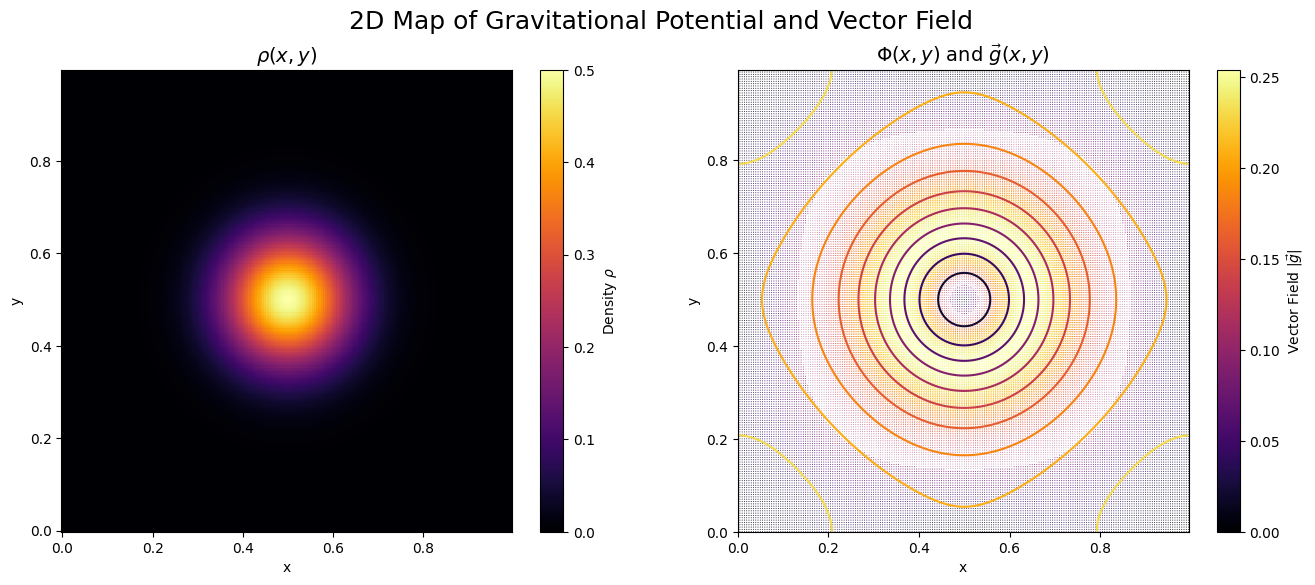

In [219]:
# Plot settings
plt.figure(figsize=(16, 6))
# Setting for Density Map
plt.subplot(1, 2, 1)
plt.pcolormesh(poisson_solver.x_2D, poisson_solver.y_2D, poisson_solver.rho, cmap='inferno')
plt.colorbar(label=r'Density $\rho$')
plt.title(r'$\rho(x,y)$', fontsize=14)
plt.xlabel('x')
plt.ylabel('y')
# Setting for Potential and Gravitational Field
plt.subplot(1, 2, 2)
c = plt.contour(poisson_solver.x_2D, poisson_solver.y_2D, poisson_solver.phi, levels=12, cmap='inferno')
# Define the magnitude of the gravitational field 
g_mag = np.sqrt(poisson_solver.gx**2 + poisson_solver.gy**2)
g = plt.quiver(poisson_solver.x_2D, poisson_solver.y_2D, poisson_solver.gx, poisson_solver.gy, g_mag, cmap='inferno')
CBG = plt.colorbar(g, label=r'Vector Field $|\vec{g}|$')
plt.title(r'$\Phi(x,y)$ and $\vec{g}(x,y)$', fontsize=14)
plt.xlabel('x')
plt.ylabel('y')
plt.suptitle('2D Map of Gravitational Potential and Vector Field', fontsize=18)
plt.show()

**(h)** Analyse your results:

- Verify numerically that your solution satisfies the Poisson equation.

- Briefly explain why FFT methods are more efficient than iterative finite-difference solvers for this problem

##### To verify if it satisfies the Poisson equation, we must find out if the solution approximate to 0.

$$\mathcal{F}^{-1} \{ -k^2 \hat{\Phi} \} - 4\pi G \rho = 0$$

In [220]:
# Define RHS and LHS for error analysis
lhs_numeric = np.fft.ifft2(-poisson_solver.k2 * poisson_solver.phi_fft).real
rhs_numeric = 4 * np.pi * poisson_solver.G * poisson_solver.rho
# Check the shapes of the arrays for LHS and RHS
#print(lhs_numeric.shape)
#print(rhs_numeric.shape)

In [221]:
# Infinity norm
L_inf = np.max(np.abs(lhs_numeric - rhs_numeric))
print("Infinity Norm: ", np.round(L_inf, 5))

Infinity Norm:  0.39478


In [222]:
# L_1 norm error
n = poisson_solver.N
L1_error = np.sum(np.abs(lhs_numeric - rhs_numeric)/(n**2))
print("Global L1 Error: ", L1_error)

Global L1 Error:  0.3947837209383709


In [223]:
# L_2 norm error
L2_error = np.sqrt((np.sum((lhs_numeric - rhs_numeric)**2)/(n**2)))
print("Global L2 Error: ", L2_error)

Global L2 Error:  0.3947837209383709


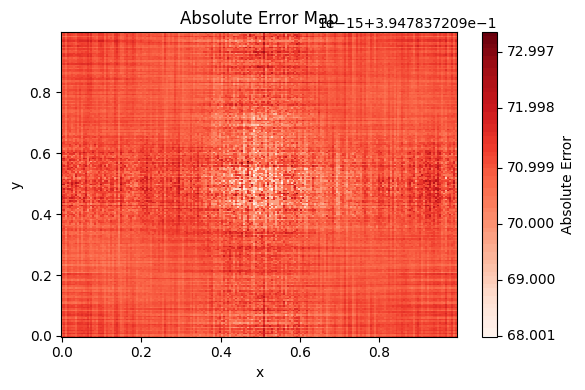

In [224]:
# Absolute error map
plt.figure(figsize=(6, 4))
err_surf = plt.pcolor(poisson_solver.x_2D, poisson_solver.y_2D, np.abs(lhs_numeric - rhs_numeric), cmap="Reds")
plt.colorbar(err_surf, label='Absolute Error')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Absolute Error Map')
plt.tight_layout()
plt.show()

#### I tried to see what the error is, but I couldn't identify its source since, as you can see in the plot, I have a large error especially on the sides, and it decreases in the center.

- Briefly explain why FFT methods are more efficient than iterative finite-difference solvers for this problem

#### Both are numerical methods that aim to discretize the Laplacian, the difference lies in how each one does it. Both methods use a second derivative with a second-order approximation, but the finite difference method defines a stencil to be moved across the entire domain, which can make it an effective but heavy method. In contrast, Fourier transforms the derivatives from real space into multiplications in Fourier space, which simplifies the process since it is a periodic function. Being Fourier the most efficient method.